## 1. Tổ Chức Dữ Liệu (Data Ingestion)

Thu thập và hợp nhất hai nguồn dữ liệu:
- **PM2.5 từ OpenAQ**: đo tại 5 trạm quan trắc TP.HCM, lấy trung bình theo giờ.
- **Khí tượng từ Open-Meteo API**: nhiệt độ, độ ẩm, tốc độ gió, áp suất, lượng mưa.

> **Lưu ý:** Toàn bộ bước merge và làm sạch thực hiện trên dữ liệu gốc, chưa scale.


In [1]:
# ══════════════════════════════════════════════════════════════════
# 1.1 IMPORT THƯ VIỆN & CẤU HÌNH
# ══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import requests
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno 
from pathlib import Path

from scipy import stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from IPython.display import display, Markdown

import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

print("Import hoàn tất!")

# Global Configuration
CONFIG = {
    'gap_threshold_days':     7,
    'interpolate_limit_hours': 3,
    'ffill_limit_hours':       3,
    'train_ratio':  0.80,
    'val_ratio':    0.10,
    'test_ratio':   0.10,
    'iqr_multiplier': 1.5,
    'random_state': 42,
    'target': 'pm25'
}
print("Cấu hình toàn cục đã thiết lập xong!")
current_dir = Path(__file__).parent if '__file__' in locals() else Path.cwd()

path_aq = current_dir / '../data/raw/raw_openaq.csv' 
path_weather = current_dir / '../data/raw/raw_openmeteo.csv'
save_path_merged = current_dir / '../data/processed/cleaned_final.csv'

# ══════════════════════════════════════════════════════════════════
#  1.2 ĐỌC VÀ LÀM SẠCH DỮ LIỆU PM2.5 (OpenAQ)
# ══════════════════════════════════════════════════════════════════

try:
    df_aq = pd.read_csv(path_aq, low_memory=False)
except FileNotFoundError:
    raise FileNotFoundError(f"Không tìm thấy file '{path_aq}'. Hãy kiểm tra lại vị trí file.")

print(f"→ Đọc thành công: {len(df_aq):,} dòng | {df_aq.shape[1]} cột")

df_pm25 = df_aq.copy()
df_pm25['pm25'] = pd.to_numeric(df_pm25['value'], errors='coerce')

# Loại bỏ giá trị không hợp lệ
df_pm25['pm25'] = df_pm25['pm25'].replace([-999, -999.0], np.nan)
df_pm25.loc[df_pm25['pm25'] < 0,   'pm25'] = np.nan
df_pm25.loc[df_pm25['pm25'] > 400, 'pm25'] = np.nan

print(f"→ Giá trị hợp lệ: {df_pm25['pm25'].notna().sum():,} / {len(df_pm25):,}")

# Chuyển múi giờ UTC → Asia/Ho_Chi_Minh
df_pm25['time'] = pd.to_datetime(df_pm25['datetimeUtc'], utc=True, errors='coerce')
df_pm25['time'] = df_pm25['time'].dt.tz_convert('Asia/Ho_Chi_Minh').dt.tz_localize(None)

# Gộp tất cả trạm: lấy trung bình PM2.5 theo từng giờ
df_aq_clean = (
    df_pm25
    .dropna(subset=['pm25', 'time'])
    .groupby('time', as_index=False)
    .agg(pm25=('pm25', 'mean'), n_obs=('pm25', 'size'))
    .sort_values('time')
    .reset_index(drop=True)
)

print(f"→ Sau group-by giờ: {df_aq_clean.shape}")
print(f"→ Thời gian: {df_aq_clean['time'].min()} → {df_aq_clean['time'].max()}")

if 'location_id' in df_pm25.columns:
    print(f"→ Số trạm gộp: {df_pm25['location_id'].nunique()}")
elif 'location' in df_pm25.columns:
    print(f"→ Số trạm gộp: {df_pm25['location'].nunique()}")
# ══════════════════════════════════════════════════════════════════
#  1.3 ĐỌC DỮ LIỆU KHÍ TƯỢNG (OpenMeteo)
# ══════════════════════════════════════════════════════════════════
print("\nĐang đọc file Khí tượng...")

try:
    df_weather = pd.read_csv(path_weather)
except FileNotFoundError:
    raise FileNotFoundError(f"Không tìm thấy file '{path_weather}'. Hãy kiểm tra lại vị trí file.")

df_weather['time'] = pd.to_datetime(df_weather['time'])
print(f"→ Đọc thành công: {len(df_weather):,} dòng | {df_weather.shape[1]} cột")
# ══════════════════════════════════════════════════════════════════
#  1.4 MERGE VÀ TẠO TIME FEATURES CƠ BẢN
# ══════════════════════════════════════════════════════════════════
print("\nMerge PM2.5 + Khí tượng...")
df_merged = pd.merge(df_weather, df_aq_clean, on='time', how='left')

# Time features cơ bản
df_merged['hour']      = df_merged['time'].dt.hour
df_merged['month']     = df_merged['time'].dt.month
df_merged['dayofweek'] = df_merged['time'].dt.dayofweek

print(f"→ Kết quả merge: {len(df_merged):,} dòng | {df_merged.shape[1]} cột")

# Lưu kết quả cuối cùng vào lại thư mục data
df_merged.to_csv(save_path_merged, index=False)
print(f"→ Đã lưu dữ liệu hợp nhất tại: {save_path_merged.resolve()}")

# Hiển thị thử dữ liệu
print("\n5 dòng đầu tiên của dữ liệu hợp nhất:")
display(df_merged.head())
%store df_merged

Import hoàn tất!
Cấu hình toàn cục đã thiết lập xong!
→ Đọc thành công: 21,678 dòng | 7 cột
→ Giá trị hợp lệ: 13,268 / 21,678
→ Sau group-by giờ: (11555, 3)
→ Thời gian: 2024-11-19 17:00:00 → 2026-05-10 07:00:00
→ Số trạm gộp: 5

Đang đọc file Khí tượng...
→ Đọc thành công: 12,912 dòng | 6 cột

Merge PM2.5 + Khí tượng...
→ Kết quả merge: 12,912 dòng | 11 cột
→ Đã lưu dữ liệu hợp nhất tại: D:\Khí hậu đồ án (1)\data\processed\cleaned_final.csv

5 dòng đầu tiên của dữ liệu hợp nhất:


,time,temperature,humidity,wind_speed,pressure,precipitation,pm25,n_obs,hour,month,dayofweek
0,2024-11-19 00:00:00,26.8,90,5.4,1008.5,0.0,NaN,NaN,0,11,1
1,2024-11-19 01:00:00,26.5,89,5.3,1008.5,0.0,NaN,NaN,1,11,1
2,2024-11-19 02:00:00,26.1,93,0.8,1008.0,0.0,NaN,NaN,2,11,1
3,2024-11-19 03:00:00,25.9,93,5.3,1007.2,0.0,NaN,NaN,3,11,1
4,2024-11-19 04:00:00,25.5,96,3.6,1007.3,0.0,NaN,NaN,4,11,1


Stored 'df_merged' (DataFrame)


## 2. Khám Phá Dữ Liệu Thô (EDA Sơ Bộ)

Đánh giá tổng quan mức độ khuyết thiếu sau khi merge và phân phối gốc của PM2.5.  
Bước này thực hiện trên dữ liệu gốc, chưa chia tập, chỉ nhằm mục đích hiểu dữ liệu.


TỔNG QUAN DỮ LIỆU:
   → Số dòng      : 12,912
   → Từ           : 2024-11-19 00:00:00
   → Đến          : 2026-05-10 23:00:00
   → PM2.5 hợp lệ : 11,555 (89.5%)
   → PM2.5 thiếu  : 1,357 (10.5%)

Missing Values theo cột:
       Thiếu (dòng)  Thiếu (%)
pm25           1357      10.51
n_obs          1357      10.51


<Figure size 1200x500 with 0 Axes>

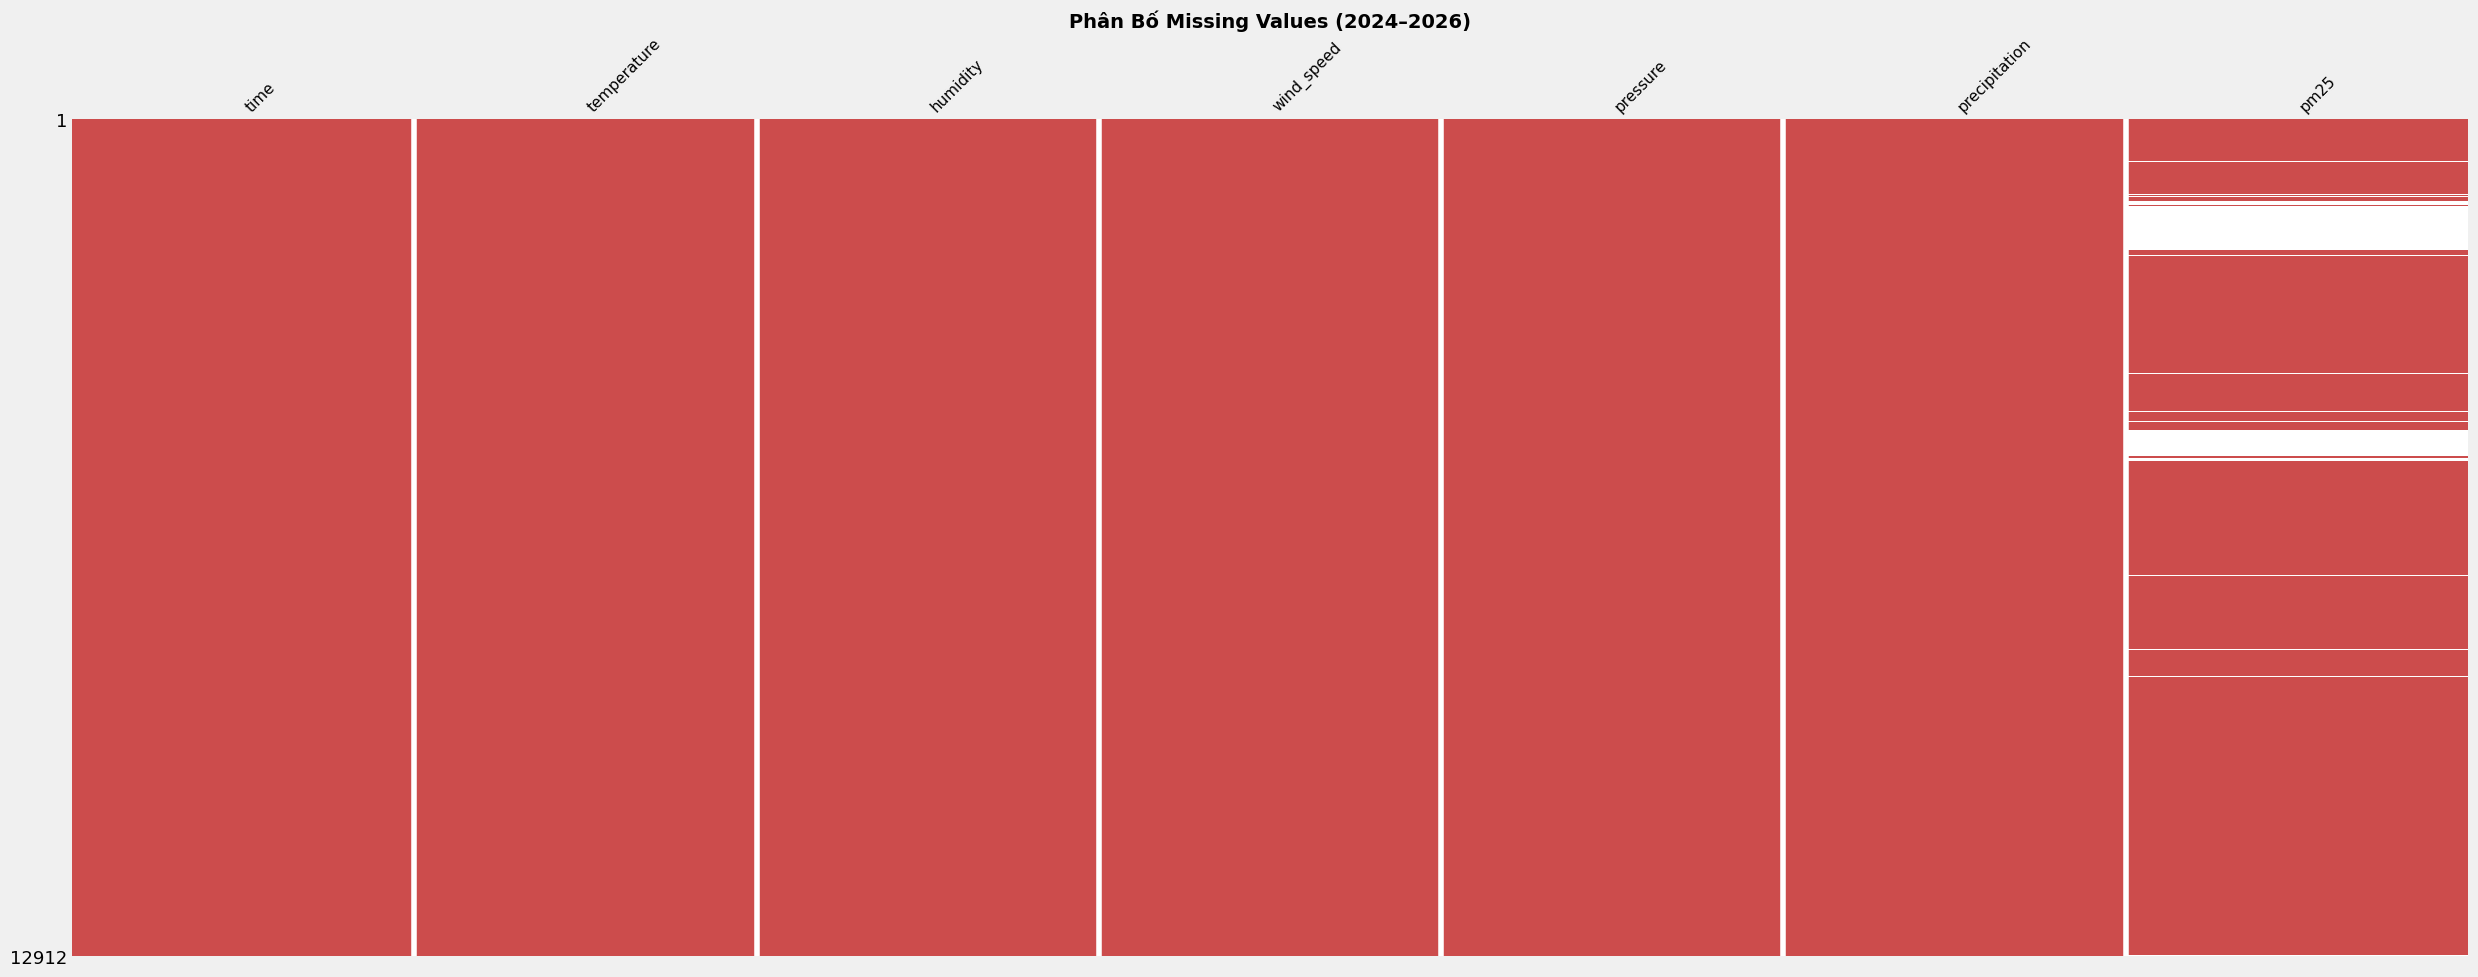

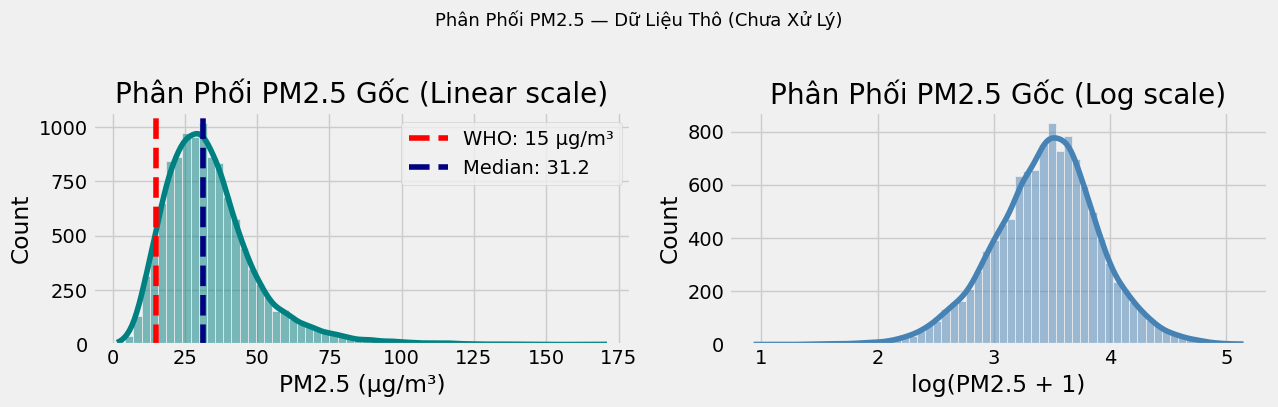


Tỷ lệ missing PM2.5 theo tháng:
         tổng_giờ  hợp_lệ  thiếu tỷ_lệ_thiếu
ym                                          
2024-11       271     271     17        5.9%
2024-12       735     735      9        1.2%
2025-01       255     255    489       65.7%
2025-02       383     383    289       43.0%
2025-03       744     744      0        0.0%
2025-04       720     720      0        0.0%
2025-05       716     716     28        3.8%
2025-06       270     270    450       62.5%
2025-07       744     744      0        0.0%
2025-08       744     744      0        0.0%
2025-09       708     708     12        1.7%
2025-10       738     738      6        0.8%
2025-11       695     695     25        3.5%
2025-12       740     740      4        0.5%
2026-01       743     743      1        0.1%
2026-02       672     672      0        0.0%
2026-03       738     738      6        0.8%
2026-04       716     716      4        0.6%
2026-05       223     223     17        7.1%


In [2]:
# ══════════════════════════════════════════════════════════════════
# 2.1  TỔNG QUAN DỮ LIỆU SAU MERGE
# ══════════════════════════════════════════════════════════════════
print("TỔNG QUAN DỮ LIỆU:")
print(f"   → Số dòng      : {len(df_merged):,}")
print(f"   → Từ           : {df_merged['time'].min()}")
print(f"   → Đến          : {df_merged['time'].max()}")
print(f"   → PM2.5 hợp lệ : {df_merged['pm25'].notna().sum():,} ({df_merged['pm25'].notna().mean()*100:.1f}%)")
print(f"   → PM2.5 thiếu  : {df_merged['pm25'].isna().sum():,} ({df_merged['pm25'].isna().mean()*100:.1f}%)")

print("\nMissing Values theo cột:")
miss = pd.DataFrame({
    'Thiếu (dòng)': df_merged.isnull().sum(),
    'Thiếu (%)':    (df_merged.isnull().mean() * 100).round(2)
})
print(miss[miss['Thiếu (dòng)'] > 0])

# ══════════════════════════════════════════════════════════════════
# 2.2  VISUALIZE MISSING VALUES
# ══════════════════════════════════════════════════════════════════
yr_s = df_merged['time'].min().year
yr_e = df_merged['time'].max().year

plt.figure(figsize=(12, 5))
msno.matrix(df_merged[['time','temperature','humidity','wind_speed',
                        'pressure','precipitation','pm25']],
            sparkline=False, fontsize=11, color=(0.8, 0.3, 0.3))
plt.title(f"Phân Bố Missing Values ({yr_s}–{yr_e})", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 2.3  PHÂN PHỐI PM2.5 GỐC
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(df_merged['pm25'].dropna(), bins=60, kde=True, color='teal', ax=axes[0])
axes[0].axvline(15, color='red',  linestyle='--', label='WHO: 15 µg/m³')
axes[0].axvline(df_merged['pm25'].median(), color='navy', linestyle='--',
                label=f"Median: {df_merged['pm25'].median():.1f}")
axes[0].set_title("Phân Phối PM2.5 Gốc (Linear scale)")
axes[0].set_xlabel("PM2.5 (µg/m³)")
axes[0].legend()

sns.histplot(np.log1p(df_merged['pm25'].dropna()), bins=60, kde=True,
             color='steelblue', ax=axes[1])
axes[1].set_title("Phân Phối PM2.5 Gốc (Log scale)")
axes[1].set_xlabel("log(PM2.5 + 1)")

plt.suptitle("Phân Phối PM2.5 — Dữ Liệu Thô (Chưa Xử Lý)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Tỷ lệ missing theo tháng
print("\nTỷ lệ missing PM2.5 theo tháng:")
df_merged['ym'] = df_merged['time'].dt.to_period('M')
audit = df_merged.groupby('ym')['pm25'].agg(
    tổng_giờ='count',
    hợp_lệ=lambda x: x.notna().sum(),
    thiếu=lambda x: x.isna().sum(),
    tỷ_lệ_thiếu=lambda x: f"{x.isna().mean()*100:.1f}%"
)
print(audit.to_string())
df_merged.drop(columns=['ym'], inplace=True)

## 3. Chẩn Đoán Cơ Chế Khuyết Thiếu (MCAR / MAR / MNAR)


Tổng dòng bị khuyết PM2.5: 1,357 (10.5%)

Kiểm tra MAR: Tương quan Point-Biserial (missingness vs biến khí tượng)
  temperature         : r = -0.0511, p = 0.0000  *** SIGNIFICANT  (↓ khi biến tăng)
  humidity            : r = -0.0463, p = 0.0000  *** SIGNIFICANT  (↓ khi biến tăng)
  wind_speed          : r = -0.0488, p = 0.0000  *** SIGNIFICANT  (↓ khi biến tăng)
  pressure            : r = -0.0016, p = 0.8562      not significant  (↓ khi biến tăng)
  precipitation       : r = -0.0056, p = 0.5211      not significant  (↓ khi biến tăng)

  Variance missingness theo giờ: 0.000046
  → Không có pattern thiếu rõ ràng theo giờ


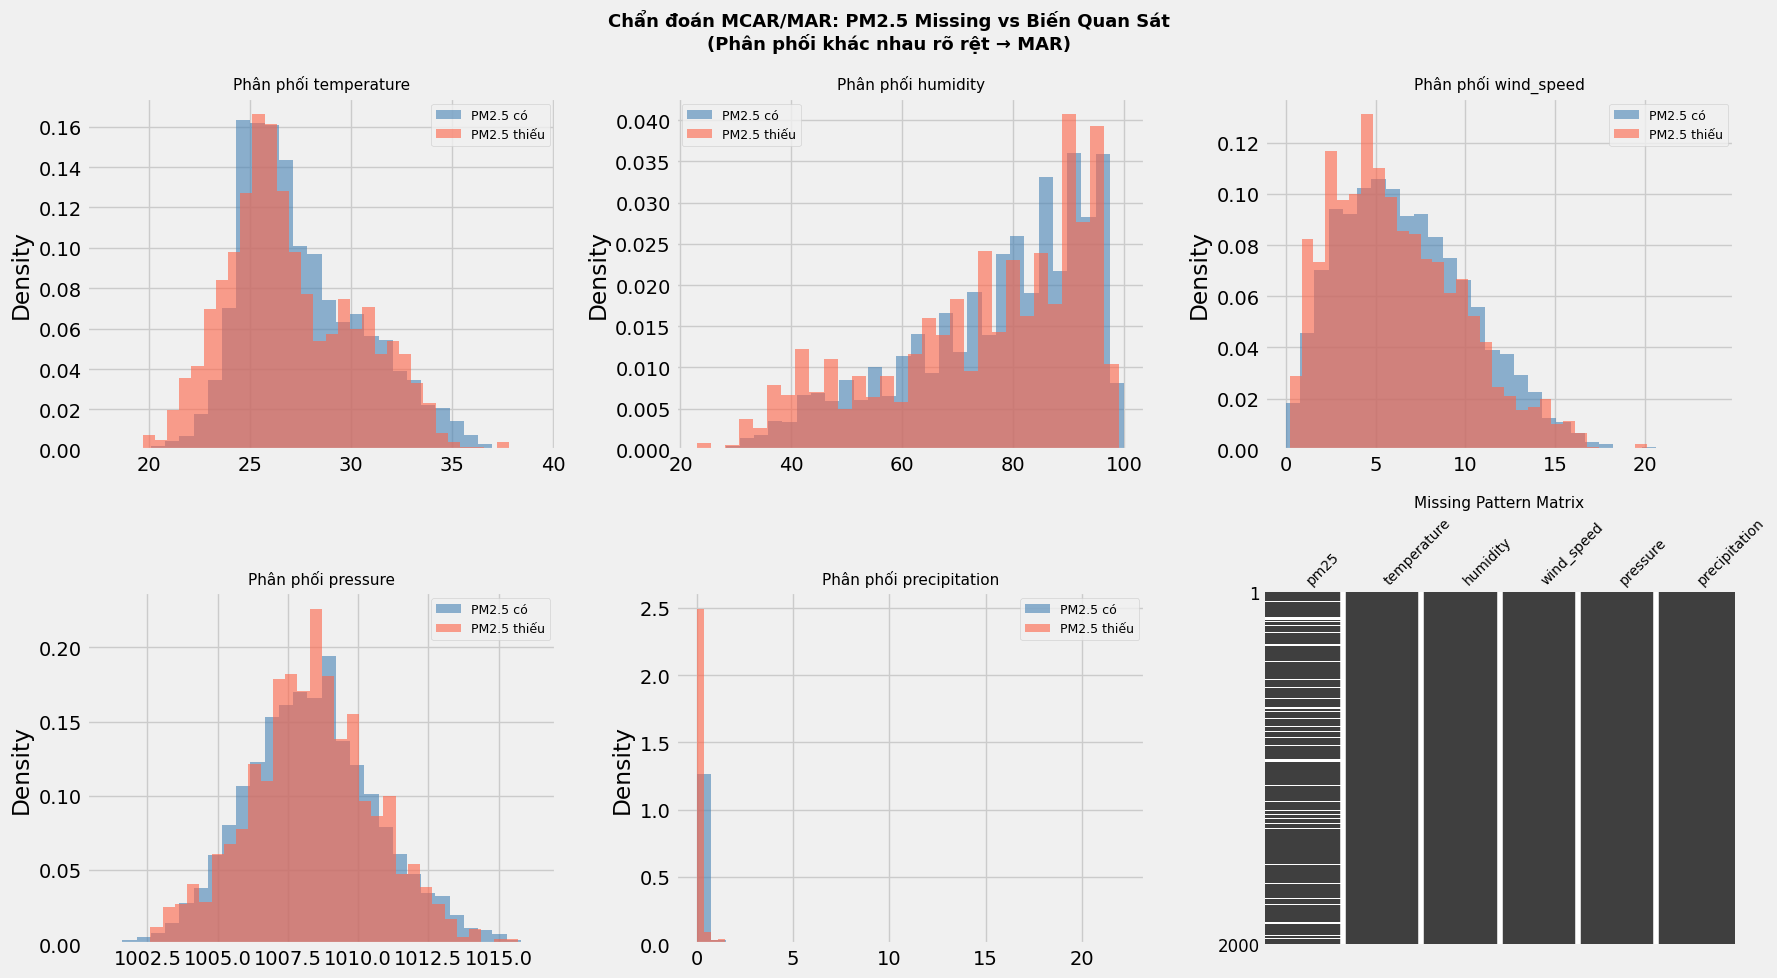


KẾT LUẬN: Cơ chế khuyết = MAR (Missing At Random)
  → PM2.5 bị khuyết có tương quan với ít nhất 1 biến khí tượng
  → Lựa chọn Imputation phù hợp:
     1. Time-series interpolation (linear, limit=3h) cho khoảng thiếu nhỏ
     2. Đứt gãy lớn (>7 ngày): loại bỏ đoạn đó thay vì hallucinate


In [3]:
# ══════════════════════════════════════════════════════════════════
# 3.1  TẠO MISSINGNESS INDICATOR
# ══════════════════════════════════════════════════════════════════
df_miss_analysis = df_merged.copy()
df_miss_analysis['pm25_missing'] = df_merged['pm25'].isna().astype(int)
df_miss_analysis['hour']         = df_merged['time'].dt.hour
df_miss_analysis['month']        = df_merged['time'].dt.month
df_miss_analysis['dayofweek']    = df_merged['time'].dt.dayofweek

print(f"Tổng dòng bị khuyết PM2.5: {df_miss_analysis['pm25_missing'].sum():,} "
      f"({df_miss_analysis['pm25_missing'].mean()*100:.1f}%)")

# ══════════════════════════════════════════════════════════════════
# 3.2  KIỂM TRA MAR: Point-Biserial Correlation
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("Kiểm tra MAR: Tương quan Point-Biserial (missingness vs biến khí tượng)")
print("=" * 70)

weather_cols = ['temperature', 'humidity', 'wind_speed', 'pressure', 'precipitation']
mar_signals  = []

for col in weather_cols:
    combined = df_miss_analysis[[col, 'pm25_missing']].dropna()
    corr, pval = stats.pointbiserialr(combined['pm25_missing'], combined[col])
    sig  = "*** SIGNIFICANT" if pval < 0.05 else "    not significant"
    mar_signals.append(pval < 0.05)
    direction = "↑" if corr > 0 else "↓"
    print(f"  {col:20s}: r = {corr:+.4f}, p = {pval:.4f}  {sig}  ({direction} khi biến tăng)")

# ══════════════════════════════════════════════════════════════════
# 3.3  TEMPORAL PATTERN
# ══════════════════════════════════════════════════════════════════
hourly_missing = df_miss_analysis.groupby('hour')['pm25_missing'].mean()
hour_variance  = hourly_missing.var()

print(f"\n  Variance missingness theo giờ: {hour_variance:.6f}")
if hour_variance > 0.001:
    print("  → Có pattern thiếu theo giờ → thêm bằng chứng MAR")
else:
    print("  → Không có pattern thiếu rõ ràng theo giờ")

# ══════════════════════════════════════════════════════════════════
# 3.4  VISUALIZATION
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Chẩn đoán MCAR/MAR: PM2.5 Missing vs Biến Quan Sát\n'
             '(Phân phối khác nhau rõ rệt → MAR)',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten()[:-1], weather_cols + ['hour']):
    present = df_miss_analysis[df_miss_analysis['pm25_missing'] == 0][col].dropna()
    missing = df_miss_analysis[df_miss_analysis['pm25_missing'] == 1][col].dropna()
    ax.hist(present, bins=30, alpha=0.6, label='PM2.5 có',    color='steelblue', density=True)
    ax.hist(missing, bins=30, alpha=0.6, label='PM2.5 thiếu', color='tomato',    density=True)
    ax.set_title(f'Phân phối {col}', fontsize=11)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

msno.matrix(df_miss_analysis[['pm25'] + weather_cols].sample(min(2000, len(df_miss_analysis))),
            ax=axes[1, 2], sparkline=False, fontsize=10)
axes[1, 2].set_title('Missing Pattern Matrix', fontsize=11)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 3.5  KẾT LUẬN
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
if any(mar_signals):
    print("KẾT LUẬN: Cơ chế khuyết = MAR (Missing At Random)")
    print("  → PM2.5 bị khuyết có tương quan với ít nhất 1 biến khí tượng")
    print("  → Lựa chọn Imputation phù hợp:")
    print("     1. Time-series interpolation (linear, limit=3h) cho khoảng thiếu nhỏ")
    print("     2. Đứt gãy lớn (>7 ngày): loại bỏ đoạn đó thay vì hallucinate")
else:
    print("KẾT LUẬN: Cơ chế khuyết có thể là MCAR (Missing Completely At Random)")
    print("  → Có thể dùng interpolation đơn giản")
print("=" * 70)


## 4. Kiểm Định Tính Dừng (Stationarity Tests)

**Tại sao cần kiểm tra?**
- Chuỗi thời gian không dừng (non-stationary) có trung bình/phương sai thay đổi theo thời gian → các mô hình giả định tính dừng sẽ cho kết quả không đáng tin cậy.
- Kết quả test cũng **justify lựa chọn features**: nếu có trend → cần `diff` features; nếu có seasonality → cần lag 24h/168h.

**Hai test được dùng:**
- **ADF (Augmented Dickey-Fuller)**: H₀ = chuỗi có unit root (non-stationary). p < 0.05 → bác bỏ H₀ → chuỗi dừng.
- **KPSS**: H₀ = chuỗi dừng. p < 0.05 → bác bỏ H₀ → chuỗi không dừng.

Dùng cả hai để cross-validate kết quả.


Kiểm định trên 5000 quan sát đầu tiên của chuỗi PM2.5

ADF TEST (H₀: Unit root — Non-stationary)
  ADF Statistic : -8.2486
  p-value       : 0.000000
  Critical values:
     1%: -3.432 ←
     5%: -2.862 ←
     10%: -2.567 ←
   Kết luận ADF: Bác bỏ H₀ → Chuỗi DỪNG (stationary)

KPSS TEST (H₀: Stationary)
  KPSS Statistic: 3.3934
  p-value       : 0.010000
  Critical values:
     10%: 0.347 ←
     5%: 0.463 ←
     2.5%: 0.574 ←
     1%: 0.739 ←
   KẾT LUẬN KPSS: Bác bỏ H₀ → Chuỗi NON-STATIONARY


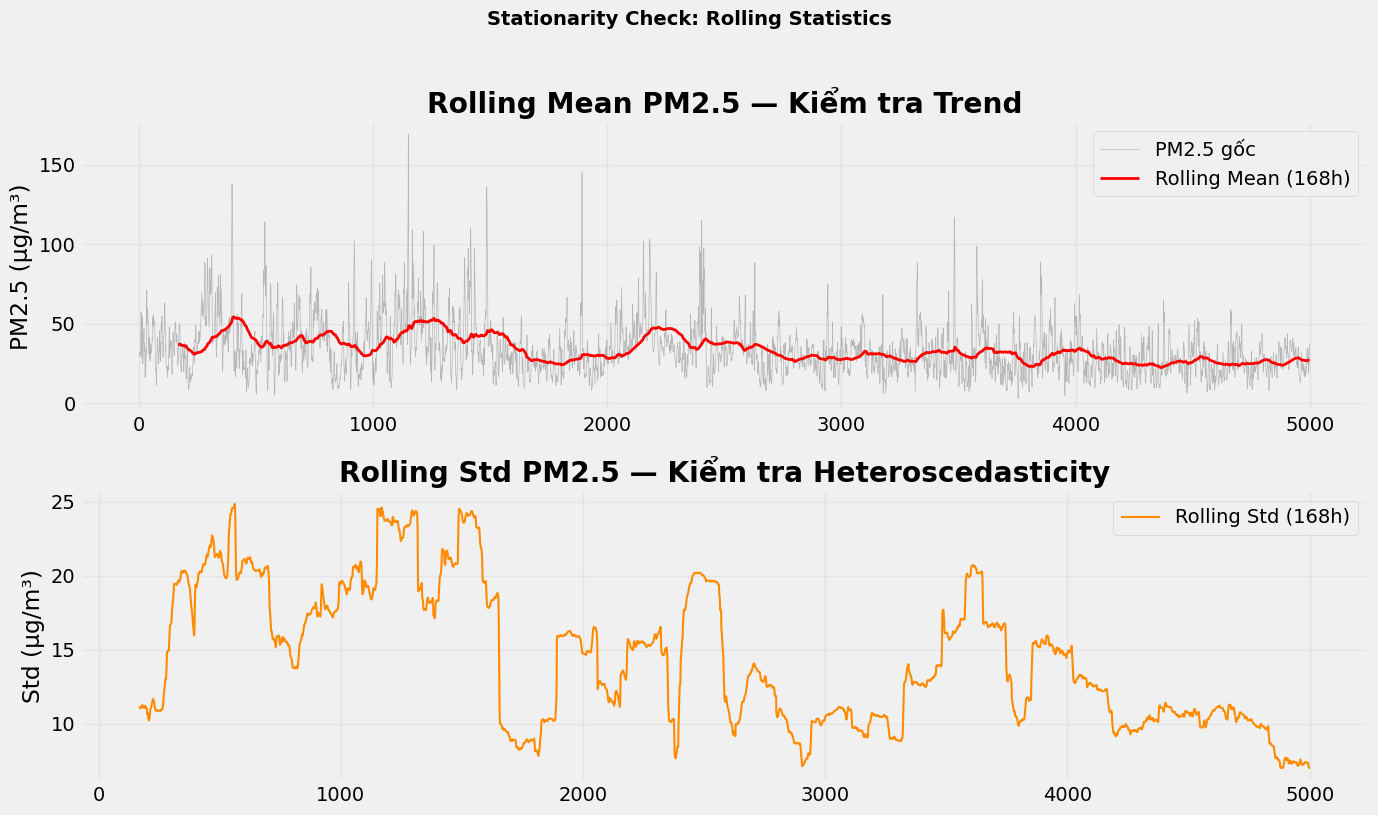


TỔNG KẾT STATIONARITY:
  Kết luận : DIFFERENCE-STATIONARY (ADF dừng, KPSS không dừng)

  → Đã tích hợp vào Feature Engineering: pm25_diff_1, pm25_diff_24


In [4]:
# ══════════════════════════════════════════════════════════════════
# 4.1  CHUẨN BỊ CHUỖI ĐỂ KIỂM ĐỊNH
# ══════════════════════════════════════════════════════════════════
# Lấy chuỗi PM2.5 liên tục (sau khi đã biết vùng dữ liệu ổn định)
pm25_series_raw = df_merged['pm25'].dropna().values

# Lấy tối đa 5000 điểm đầu để test nhanh (ADF chậm trên chuỗi rất dài)
n_test = min(5000, len(pm25_series_raw))
pm25_for_test = pm25_series_raw[:n_test]

print(f"Kiểm định trên {n_test} quan sát đầu tiên của chuỗi PM2.5")

# ══════════════════════════════════════════════════════════════════
# 4.2  ADF TEST
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("ADF TEST (H₀: Unit root — Non-stationary)")
print("=" * 60)

adf_result = adfuller(pm25_for_test, autolag='AIC')
adf_stat, adf_pval = adf_result[0], adf_result[1]
adf_critical = adf_result[4]

print(f"  ADF Statistic : {adf_stat:.4f}")
print(f"  p-value       : {adf_pval:.6f}")
print(f"  Critical values:")
for key, val in adf_critical.items():
    marker = " ←" if adf_stat < val else ""
    print(f"     {key}: {val:.3f}{marker}")

if adf_pval < 0.05:
    print("   Kết luận ADF: Bác bỏ H₀ → Chuỗi DỪNG (stationary)")
    adf_stationary = True
else:
    print("   Kết luận ADF: Không bác bỏ H₀ → Chuỗi có thể NON-STATIONARY")
    adf_stationary = False

# ══════════════════════════════════════════════════════════════════
# 4.3  KPSS TEST
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("KPSS TEST (H₀: Stationary)")
print("=" * 60)

kpss_result = kpss(pm25_for_test, regression='c', nlags='auto')
kpss_stat, kpss_pval = kpss_result[0], kpss_result[1]
kpss_critical = kpss_result[3]

print(f"  KPSS Statistic: {kpss_stat:.4f}")
print(f"  p-value       : {kpss_pval:.6f}")
print(f"  Critical values:")
for key, val in kpss_critical.items():
    marker = " ←" if kpss_stat > val else ""
    print(f"     {key}: {val:.3f}{marker}")

if kpss_pval < 0.05:
    print("   KẾT LUẬN KPSS: Bác bỏ H₀ → Chuỗi NON-STATIONARY")
    kpss_stationary = False
else:
    print("   KẾT LUẬN KPSS: Không bác bỏ H₀ → Chuỗi DỪNG (stationary)")
    kpss_stationary = True

# ══════════════════════════════════════════════════════════════════
# 4.4  VISUALIZATION: Rolling mean & std
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Dùng pandas series để rolling
pm25_pd = pd.Series(pm25_for_test)
roll_mean = pm25_pd.rolling(window=168).mean()   # 7 ngày
roll_std  = pm25_pd.rolling(window=168).std()

axes[0].plot(pm25_pd.values,    color='gray',     alpha=0.5, linewidth=0.5, label='PM2.5 gốc')
axes[0].plot(roll_mean.values,  color='red',      linewidth=2, label='Rolling Mean (168h)')
axes[0].set_title('Rolling Mean PM2.5 — Kiểm tra Trend', fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(roll_std.values, color='darkorange', linewidth=1.5, label='Rolling Std (168h)')
axes[1].set_title('Rolling Std PM2.5 — Kiểm tra Heteroscedasticity', fontweight='bold')
axes[1].set_ylabel('Std (µg/m³)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Stationarity Check: Rolling Statistics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 4.5  TỔNG KẾT VÀ HÀM Ý CHO FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("TỔNG KẾT STATIONARITY:")
print("=" * 60)

if adf_stationary and kpss_stationary:
    conclusion = "STATIONARY (cả ADF và KPSS đồng thuận)"
    note = "→ Không cần differencing. Lag features đủ để capture autocorrelation."
elif adf_stationary and not kpss_stationary:
    conclusion = "DIFFERENCE-STATIONARY (ADF dừng, KPSS không dừng)"
    note = "→ Có trend ngắn hạn. Diff features (diff_1, diff_24) giúp capture tốc độ thay đổi."
elif not adf_stationary and kpss_stationary:
    conclusion = "TREND-STATIONARY (ADF không dừng, KPSS dừng)"
    note = "→ Chuỗi có deterministic trend. Cân nhắc detrending hoặc thêm time-index feature."
else:
    conclusion = "NON-STATIONARY (cả ADF và KPSS đồng thuận)"
    note = "→ Cần differencing. Ưu tiên diff_1, diff_24 trong feature set."

print(f"  Kết luận : {conclusion}")
print(f"\n  → Đã tích hợp vào Feature Engineering: pm25_diff_1, pm25_diff_24")
print("=" * 60)


## 5. Lọc Sạch Dữ Liệu Theo Thời Gian (Gap Detection)

**Vấn đề:** Chuỗi PM2.5 có những đứt gãy dài (sensor ngừng hoạt động), gây ra khoảng trống lớn không thể nội suy. Nếu để nguyên, các lag feature sẽ bị "vấy nhiễm" bởi các giá trị cũ không liên quan.

**Giải pháp:** Xác định và loại bỏ giai đoạn trước khoảng đứt gãy cuối cùng > 7 ngày, chỉ giữ phần dữ liệu liên tục và ổn định nhất.


In [5]:
# ══════════════════════════════════════════════════════════════════
# 5.1  PHÁT HIỆN VÀ XỬ LÝ ĐỨT GÃY DỮ LIỆU
# ══════════════════════════════════════════════════════════════════
from numpy import save


pm25_valid  = df_merged[df_merged['pm25'].notna()]['time'].sort_values()
gaps        = pm25_valid.diff()
big_gap_idx = gaps[gaps > pd.Timedelta(days=CONFIG['gap_threshold_days'])].index

if len(big_gap_idx) > 0:
    start_stable = pm25_valid[big_gap_idx[-1]]
    print(f"Phát hiện {len(big_gap_idx)} khoảng đứt gãy lớn (> {CONFIG['gap_threshold_days']} ngày):")
    for idx, gap in gaps[gaps > pd.Timedelta(days=CONFIG['gap_threshold_days'])].items():
        print(f"→ Tại {pm25_valid[idx].strftime('%Y-%m-%d %H:%M')}: gap {gap.days} ngày")
else:
    start_stable = pm25_valid.iloc[0]
    print("Không có khoảng đứt gãy lớn nào!")

print(f"\nDữ liệu ổn định từ: {start_stable}")

# ══════════════════════════════════════════════════════════════════
# 5.2  CẮT DỮ LIỆU VÀ KIỂM TRA
# ══════════════════════════════════════════════════════════════════
df_merged_clean = df_merged[df_merged['time'] >= start_stable].copy()

n_total   = len(df_merged)
n_kept    = len(df_merged_clean)
n_dropped = n_total - n_kept

print(f"\nKết quả lọc:")
print(f"→ Dữ liệu ban đầu : {n_total:,} dòng")
print(f"→ Đã loại bỏ      : {n_dropped:,} dòng ({n_dropped/n_total*100:.1f}%)")
print(f"→ Giữ lại         : {n_kept:,} dòng ({n_kept/n_total*100:.1f}%)")

assert df_merged_clean['time'].is_unique, "Có timestamp trùng lặp sau khi lọc!"
print("Kiểm tra timestamp duy nhất: OK")


Phát hiện 3 khoảng đứt gãy lớn (> 7 ngày):
→ Tại 2025-02-12 00:00: gap 28 ngày
→ Tại 2025-06-15 11:00: gap 7 ngày
→ Tại 2025-06-23 22:00: gap 8 ngày

Dữ liệu ổn định từ: 2025-06-23 22:00:00

Kết quả lọc:
→ Dữ liệu ban đầu : 12,912 dòng
→ Đã loại bỏ      : 5,206 dòng (40.3%)
→ Giữ lại         : 7,706 dòng (59.7%)
Kiểm tra timestamp duy nhất: OK


## 6. Split → Imputation → Validation Imputation

### Nguyên tắc chống Data Leakage
```
[1] SPLIT theo thời gian (Train/Val/Test)         ← trước mọi thứ
[2] Interpolate/ffill trong từng tập ĐỘC LẬP      ← không dùng thông tin chéo
[3] VALIDATE imputation bằng Synthetic Removal    ← kiểm tra chất lượng
```

Chia dataset theo cutoff dates...
Data range: 2025-06-23 22:00:00 → 2026-05-10 23:00:00
Tổng số mẫu: 7,706

Train: 4,586 mẫu | 2025-06-23 → 2025-12-31
Val:   1,416 mẫu | 2026-01-01 → 2026-02-28
Test:  1,704 mẫu | 2026-03-01 → 2026-05-10

 Test set dài 70 ngày (OK > 60 ngày)
✓\ Không có overlap giữa các tập


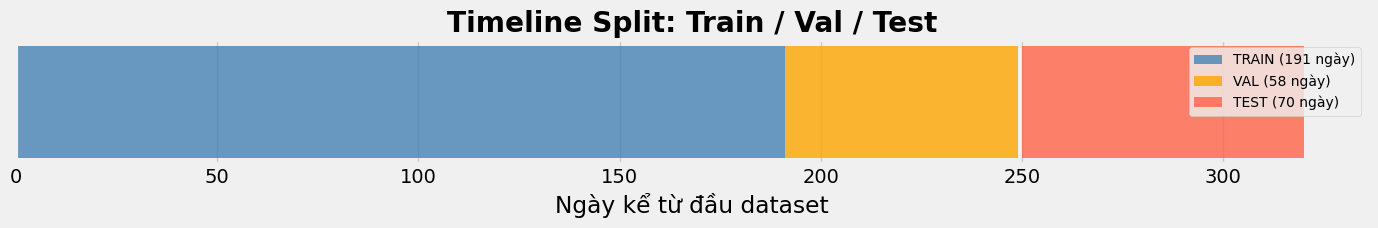

Sau interpolate + ffill + drop NaN:
Train: 4,551 | Val: 1,416 | Test: 1,689
 Thứ tự Train < Val < Test: OK
VALIDATION IMPUTATION (Synthetic Removal Test)

Synthetic Removal Test (91 điểm):
  MAE  imputation : 3.759 µg/m³
  RMSE imputation : 5.045 µg/m³
  R²   imputation : 0.9143

  → MAE 3.76 µg/m³ là sai số do interpolation, cần nhỏ hơn RMSE model


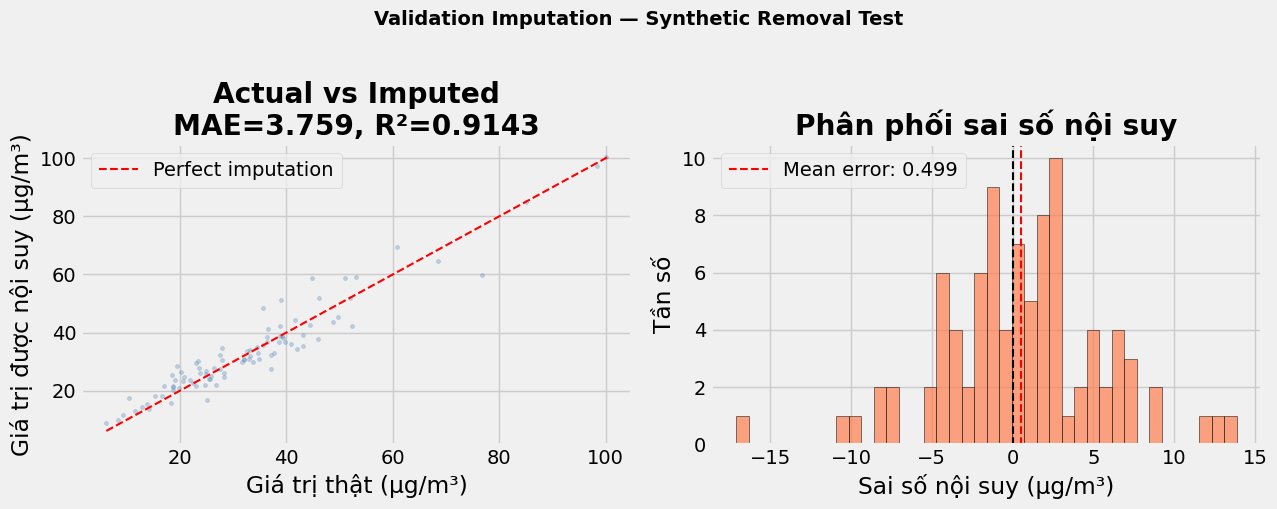

In [6]:
# ══════════════════════════════════════════════════════════════════
# 6.1  SPLIT THEO THỜI GIAN VỚI CUTOFF DATES
# ══════════════════════════════════════════════════════════════════
print("Chia dataset theo cutoff dates...")
print(f"Data range: {df_merged_clean['time'].min()} → {df_merged_clean['time'].max()}")
print(f"Tổng số mẫu: {len(df_merged_clean):,}")

TRAIN_END = '2025-12-31 23:00:00'   # Train đến cuối 2025
VAL_END   = '2026-02-28 23:00:00'   # Val đến cuối Feb 2026

df_train = df_merged_clean[df_merged_clean['time'] <= TRAIN_END].copy().reset_index(drop=True)
df_val   = df_merged_clean[(df_merged_clean['time'] > TRAIN_END) &
                            (df_merged_clean['time'] <= VAL_END)].copy().reset_index(drop=True)
df_test  = df_merged_clean[df_merged_clean['time'] > VAL_END].copy().reset_index(drop=True)

print(f"\nTrain: {len(df_train):,} mẫu | {df_train['time'].min().date()} → {df_train['time'].max().date()}")
print(f"Val:   {len(df_val):,} mẫu | {df_val['time'].min().date()} → {df_val['time'].max().date()}")
print(f"Test:  {len(df_test):,} mẫu | {df_test['time'].min().date()} → {df_test['time'].max().date()}")

test_duration = (df_test['time'].max() - df_test['time'].min()).days
if test_duration < 60:
    print(f"\n  CẢNH BÁO: Test set chỉ {test_duration} ngày (nên ít nhất 60-90 ngày)")
else:
    print(f"\n Test set dài {test_duration} ngày (OK > 60 ngày)")

assert df_train['time'].max() < df_val['time'].min(),  "Train/Val overlap!"
assert df_val['time'].max()   < df_test['time'].min(), "Val/Test overlap!"
print("✓\ Không có overlap giữa các tập")

# Visualize split timeline
fig, ax = plt.subplots(figsize=(14, 2.5))
splits = [
    (df_train['time'].min(), df_train['time'].max(), 'steelblue', 'TRAIN'),
    (df_val['time'].min(),   df_val['time'].max(),   'orange',    'VAL'),
    (df_test['time'].min(),  df_test['time'].max(),  'tomato',    'TEST'),
]
for start, end, color, label in splits:
    ax.barh(0, (end - start).days, left=(start - df_train['time'].min()).days,
            height=0.5, color=color, alpha=0.8, label=f"{label} ({(end-start).days} ngày)")
ax.set_yticks([]); ax.set_xlabel('Ngày kể từ đầu dataset')
ax.set_title('Timeline Split: Train / Val / Test', fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════
# 6.2  XỬ LÝ MISSING — NỘI SUY PM2.5 VÀ FORWARD-FILL KHÍ TƯỢNG
# ══════════════════════════════════════════════════════════════════
weather_cols = ['temperature','humidity','wind_speed','pressure','precipitation']

# Lưu lại thống kê missing TRƯỚC imputation (cho validation)
missing_before = {}
for name, df_part in [('train', df_train), ('val', df_val), ('test', df_test)]:
    missing_before[name] = df_part['pm25'].isna().sum()

for df_part in [df_train, df_val, df_test]:
    df_part.set_index('time', inplace=True)
    df_part['pm25_interpolated'] = df_part['pm25'].isna()
    df_part['pm25'] = df_part['pm25'].interpolate(method='time',
                                                   limit=CONFIG['interpolate_limit_hours'])
    for col in weather_cols:
        df_part[col] = df_part[col].ffill(limit=CONFIG['ffill_limit_hours'])
    df_part.reset_index(inplace=True)

for df_part in [df_train, df_val, df_test]:
    df_part.dropna(subset=['pm25'] + weather_cols, inplace=True)
    df_part.reset_index(drop=True, inplace=True)

print(f"Sau interpolate + ffill + drop NaN:")
print(f"Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}")

assert df_train['time'].max() < df_val['time'].min(),  "Train/Val bị overlap thời gian!"
assert df_val['time'].max()   < df_test['time'].min(), "Val/Test bị overlap thời gian!"
print(" Thứ tự Train < Val < Test: OK")

# ══════════════════════════════════════════════════════════════════
# 6.3  VALIDATION IMPUTATION — Synthetic Removal Test
# ══════════════════════════════════════════════════════════════════

print("=" * 60)
print("VALIDATION IMPUTATION (Synthetic Removal Test)")
print("=" * 60)

# Dùng chuỗi đã interpolate sạch của Train để test
pm25_clean = df_train['pm25'].copy().reset_index(drop=True)

# Lấy các vị trí đã được nội suy (đánh dấu là True trong pm25_interpolated)
# Nếu không có, tạo test ngẫu nhiên
n_test_synthetic = min(500, int(len(pm25_clean) * 0.02))  # 2% dữ liệu

np.random.seed(42)
# Chọn vị trí để giả vờ xóa (tránh đầu/cuối để có đủ context)
candidate_idx = np.arange(25, len(pm25_clean) - 25)
mask_idx = np.random.choice(candidate_idx, size=n_test_synthetic, replace=False)
mask_idx = np.sort(mask_idx)

# Lưu giá trị thật
true_values = pm25_clean.iloc[mask_idx].values

# Tạo chuỗi với các giá trị bị ẩn
pm25_masked = pm25_clean.copy()
pm25_masked.iloc[mask_idx] = np.nan

# Interpolate
pm25_imputed = pm25_masked.interpolate(method='linear', limit=3)

# Lấy giá trị đã impute (chỉ tại vị trí đã mask)
imputed_values = pm25_imputed.iloc[mask_idx].values

# Loại bỏ NaN còn lại (nếu gap > 3h không được nội suy)
valid_mask = ~np.isnan(imputed_values)
true_v     = true_values[valid_mask]
imputed_v  = imputed_values[valid_mask]

mae_imp  = np.mean(np.abs(true_v - imputed_v))
rmse_imp = np.sqrt(np.mean((true_v - imputed_v)**2))
r2_imp   = 1 - np.sum((true_v - imputed_v)**2) / np.sum((true_v - true_v.mean())**2)

print(f"\nSynthetic Removal Test ({len(true_v)} điểm):")
print(f"  MAE  imputation : {mae_imp:.3f} µg/m³")
print(f"  RMSE imputation : {rmse_imp:.3f} µg/m³")
print(f"  R²   imputation : {r2_imp:.4f}")
print(f"\n  → MAE {mae_imp:.2f} µg/m³ là sai số do interpolation, cần nhỏ hơn RMSE model")

# Visualization: scatter plot actual vs imputed
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(true_v, imputed_v, alpha=0.3, s=8, color='steelblue')
lim = [min(true_v.min(), imputed_v.min()), max(true_v.max(), imputed_v.max())]
axes[0].plot(lim, lim, 'r--', linewidth=1.5, label='Perfect imputation')
axes[0].set_xlabel('Giá trị thật (µg/m³)')
axes[0].set_ylabel('Giá trị được nội suy (µg/m³)')
axes[0].set_title(f'Actual vs Imputed\nMAE={mae_imp:.3f}, R²={r2_imp:.4f}', fontweight='bold')
axes[0].legend()

errors = imputed_v - true_v
axes[1].hist(errors, bins=40, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].axvline(errors.mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean error: {errors.mean():.3f}')
axes[1].set_xlabel('Sai số nội suy (µg/m³)')
axes[1].set_ylabel('Tần số')
axes[1].set_title('Phân phối sai số nội suy', fontweight='bold')
axes[1].legend()

plt.suptitle('Validation Imputation — Synthetic Removal Test', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 7. Phân Tích Outlier Chuyên Sâu

**Tại sao không xóa outlier?**
Từ EDA ở Section 6, outlier PM2.5 tập trung vào đêm/rạng sáng — đây là các **real pollution events** (đốt rác, giao thông thấp tốc độ khuếch tán), không phải sensor error. Xóa chúng sẽ làm mô hình học thiếu những tình huống quan trọng nhất.

**Chiến lược:** Flag (đánh dấu) outlier → dùng RobustScaler thay vì StandardScaler để giảm ảnh hưởng của chúng lên scaling.


Đã lưu pm25_raw (giá trị gốc µg/m³) vào từng tập

Ngưỡng IQR (fit trên Train): [-7.35, 68.25] µg/m³
Outlier Train : 3.05%
Outlier Val   : 7.20%
Outlier Test  : 1.07%
(Không drop outlier — chỉ flag để phân tích)


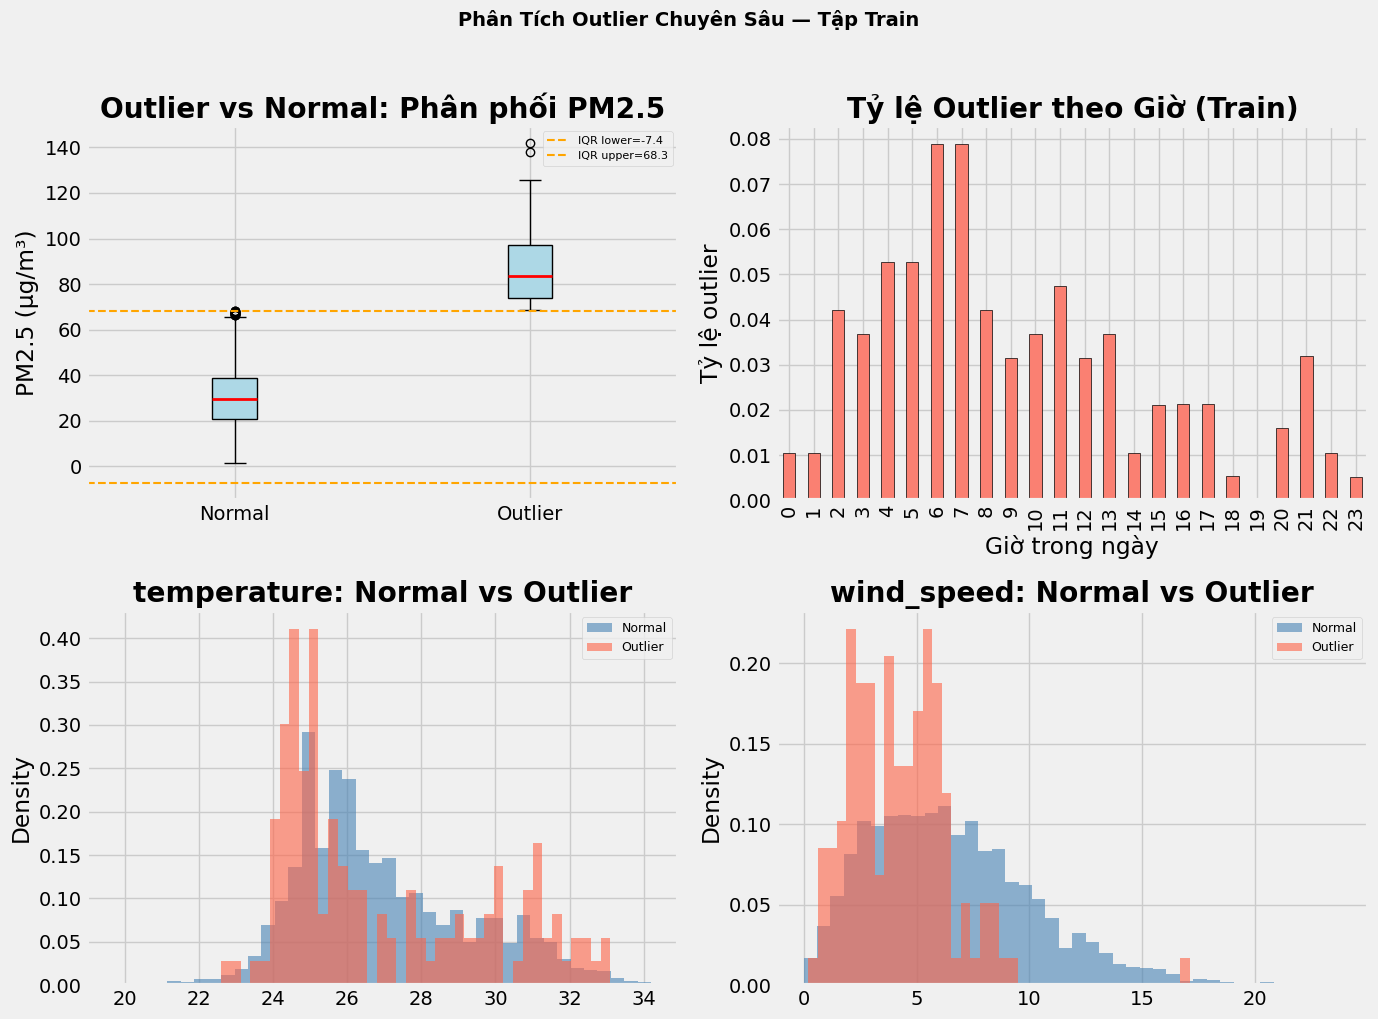

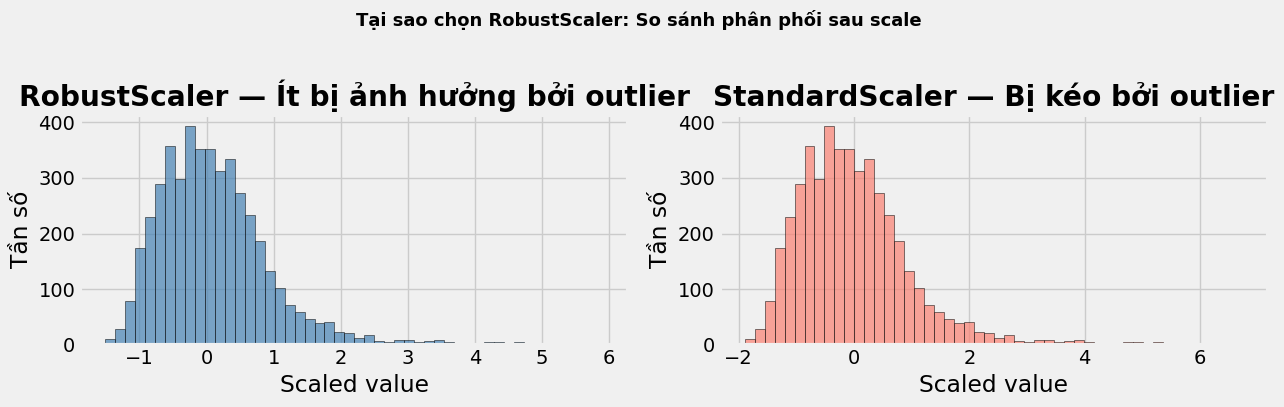

→ RobustScaler dùng median + IQR nên resistant với outlier → lựa chọn đúng cho PM2.5
Data sạch cuối cùng: 7,656 dòng | 14 cột
Đã lưu file sạch thành công: D:\Khí hậu đồ án (1)\data\processed\cleaned_final.csv
   - Bao gồm: pm25_raw, pm25_outlier_iqr, time features, weather...


In [ ]:
# ══════════════════════════════════════════════════════════════════
# 7.1  LƯU GIÁ TRỊ GỐC PM2.5 VÀ FLAG OUTLIER
# ══════════════════════════════════════════════════════════════════
for df_part in [df_train, df_val, df_test]:
    df_part['pm25_raw'] = df_part['pm25'].copy()

print("Đã lưu pm25_raw (giá trị gốc µg/m³) vào từng tập")

# Fit ngưỡng IQR chỉ trên Train (chống leakage)
q1    = df_train['pm25_raw'].quantile(0.25)
q3    = df_train['pm25_raw'].quantile(0.75)
iqr   = q3 - q1
lower = q1 - CONFIG['iqr_multiplier'] * iqr
upper = q3 + CONFIG['iqr_multiplier'] * iqr

for df_part in [df_train, df_val, df_test]:
    df_part['pm25_outlier_iqr'] = (
        (df_part['pm25_raw'] < lower) | (df_part['pm25_raw'] > upper)
    ).astype(int)

print(f"\nNgưỡng IQR (fit trên Train): [{lower:.2f}, {upper:.2f}] µg/m³")
print(f"Outlier Train : {df_train['pm25_outlier_iqr'].mean()*100:.2f}%")
print(f"Outlier Val   : {df_val['pm25_outlier_iqr'].mean()*100:.2f}%")
print(f"Outlier Test  : {df_test['pm25_outlier_iqr'].mean()*100:.2f}%")
print("(Không drop outlier — chỉ flag để phân tích)")

# ══════════════════════════════════════════════════════════════════
# 7.2  PHÂN TÍCH OUTLIER CHUYÊN SÂU
# ══════════════════════════════════════════════════════════════════
train_outlier = df_train[df_train['pm25_outlier_iqr'] == 1]
train_normal  = df_train[df_train['pm25_outlier_iqr'] == 0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplot so sánh trước/sau outlier
axes[0, 0].boxplot([train_normal['pm25_raw'].dropna().values,
                    train_outlier['pm25_raw'].dropna().values],
                   labels=['Normal', 'Outlier'], patch_artist=True,
                   boxprops=dict(facecolor='lightblue'),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 0].axhline(lower, color='orange', linestyle='--', linewidth=1.5, label=f'IQR lower={lower:.1f}')
axes[0, 0].axhline(upper, color='orange', linestyle='--', linewidth=1.5, label=f'IQR upper={upper:.1f}')
axes[0, 0].set_title('Outlier vs Normal: Phân phối PM2.5', fontweight='bold')
axes[0, 0].set_ylabel('PM2.5 (µg/m³)')
axes[0, 0].legend(fontsize=8)

# Outlier theo giờ
outlier_rate_by_hour = df_train.groupby('hour')['pm25_outlier_iqr'].mean()
outlier_rate_by_hour.plot(kind='bar', ax=axes[0, 1], color='salmon', edgecolor='black')
axes[0, 1].set_title('Tỷ lệ Outlier theo Giờ (Train)', fontweight='bold')
axes[0, 1].set_ylabel('Tỷ lệ outlier')
axes[0, 1].set_xlabel('Giờ trong ngày')

# Distribution comparison: outlier vs normal for weather features
for ax, col in zip([axes[1, 0], axes[1, 1]], ['temperature', 'wind_speed']):
    ax.hist(train_normal[col].dropna(),  bins=40, alpha=0.6, density=True,
            color='steelblue', label='Normal')
    ax.hist(train_outlier[col].dropna(), bins=40, alpha=0.6, density=True,
            color='tomato', label='Outlier')
    ax.set_title(f'{col}: Normal vs Outlier', fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Phân Tích Outlier Chuyên Sâu — Tập Train', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════
# 7.3  SO SÁNH RobustScaler vs StandardScaler với outlier
# ══════════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
robust_scaled = RobustScaler().fit_transform(df_train[['pm25_raw']]).flatten()
std_scaled    = StandardScaler().fit_transform(df_train[['pm25_raw']]).flatten()

axes[0].hist(robust_scaled, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('RobustScaler — Ít bị ảnh hưởng bởi outlier', fontweight='bold')
axes[0].set_xlabel('Scaled value')
axes[0].set_ylabel('Tần số')

axes[1].hist(std_scaled, bins=50, color='salmon', alpha=0.7, edgecolor='black')
axes[1].set_title('StandardScaler — Bị kéo bởi outlier', fontweight='bold')
axes[1].set_xlabel('Scaled value')
axes[1].set_ylabel('Tần số')

plt.suptitle('Tại sao chọn RobustScaler: So sánh phân phối sau scale', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("→ RobustScaler dùng median + IQR nên resistant với outlier → lựa chọn đúng cho PM2.5")

# Lưu từng tập
df_train.to_csv('../data/clean_and_features/train_clean.csv', index=False)
df_val.to_csv('../data/clean_and_features/val_clean.csv',     index=False)
df_test.to_csv('../data/clean_and_features/test_clean.csv',   index=False)
df_clean = pd.concat([df_train, df_val, df_test], axis=0, ignore_index=True)

n_before = len(df_train) + len(df_val) + len(df_test)
df_train = df_train[df_train['pm25_interpolated'] == False].copy()
df_val   = df_val[df_val['pm25_interpolated'] == False].copy()
df_test  = df_test[df_test['pm25_interpolated'] == False].copy()
n_after = len(df_train) + len(df_val) + len(df_test)
print(f"Đã loại {n_before - n_after} hàng target đã interpolate ({n_before - n_after}/{n_before} = {(n_before-n_after)/n_before*100:.1f}%)")
print(f"Data sạch cuối cùng: {len(df_clean):,} dòng | {df_clean.shape[1]} cột")

# Lưu file
df_clean.to_csv(save_path_merged, index=False)

print(f"Đã lưu file sạch thành công: {save_path_merged.resolve()}")
print("   - Bao gồm: pm25_raw, pm25_outlier_iqr, time features, weather...")